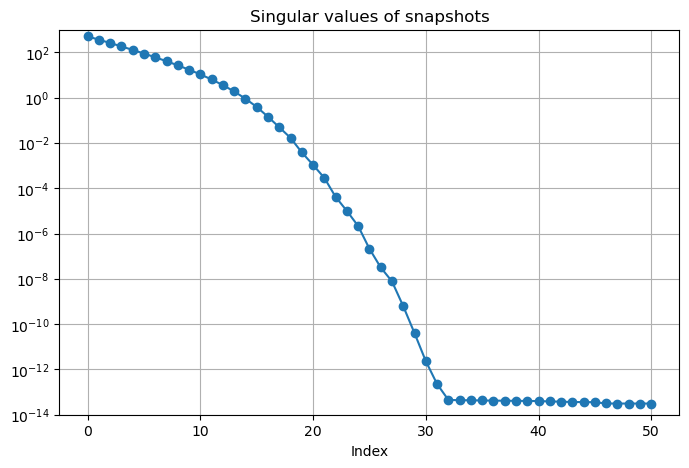

In [ ]:
import numpy as np
import sympy as sp
import time
from scipy.linalg import qr
import matplotlib.pyplot as plt

# Parameters
n = 50000  # dimension of the full system
ell = 10  # DEIM reduced dimension
num_snapshots = 51
x = np.linspace(-1, 1, n)

def getidx(i):
    if i == 0:
        return 0
    elif i < n - 1:
        return i
    else:
        return n - 1

# Nonlinear function (vectorized)
def f(mu, indices=None):
    if indices is None:
        func = (1 - x) * np.cos(3 * np.pi * mu * (x + 1)) * np.exp(-(1 + x) * mu)
    else:
        func = np.zeros_like(x[indices])
        for i, idx in enumerate(indices):
            func[i] = (1 - x[getidx(idx)]) * np.cos(3 * np.pi * mu * (x[getidx(idx)] + 1)) * np.exp(-(1 + x[getidx(idx)]) * mu)
    return func

# Generate snapshots
np.random.seed(0)
snapshots = np.zeros((n, num_snapshots))
mu = np.linspace(1, np.pi, num_snapshots)
for i in range(num_snapshots):
    snapshots[:, i] = f(mu[i])

# SVD for DEIM basis
U, S, Vh = np.linalg.svd(snapshots, full_matrices=False)
U_deim = U[:, :ell]

# Plot the singular values
plt.figure(figsize=(8, 5))
plt.semilogy(S, marker='o')
plt.title('Singular values of snapshots')
plt.xlabel('Index')
# plt.ylabel('Singular Value')
# make yrange [S.min, S.max] rounded to nearest power of 10
plt.ylim([10**(np.floor(np.log10(S.min()*0.9))), 10**(np.ceil(np.log10(S.max()*1.1)))])
plt.grid()
plt.show()

In [ ]:
def deim_indices(U):
    n, m = U.shape
    indices = []
    P = np.zeros((n, 0))
    for j in range(m):
        u = U[:, j]
        if j == 0:
            idx = np.argmax(np.abs(u))
        else:
            c = np.linalg.lstsq(P[indices, :], u[indices], rcond=None)[0]
            r = u - P @ c
            idx = np.argmax(np.abs(r))
        indices.append(idx)
        P = np.column_stack((P, U[:, j]))
    return np.array(indices)

greedy_indices = deim_indices(U_deim)

# QDEIM selection (pivoted QR)
def qdeim_indices(U):
    # QR with column pivoting on U^T
    Q, R, piv = qr(U.T, pivoting=True)
    return np.array(piv[:U.shape[1]])

qdeim_indices = qdeim_indices(U_deim)

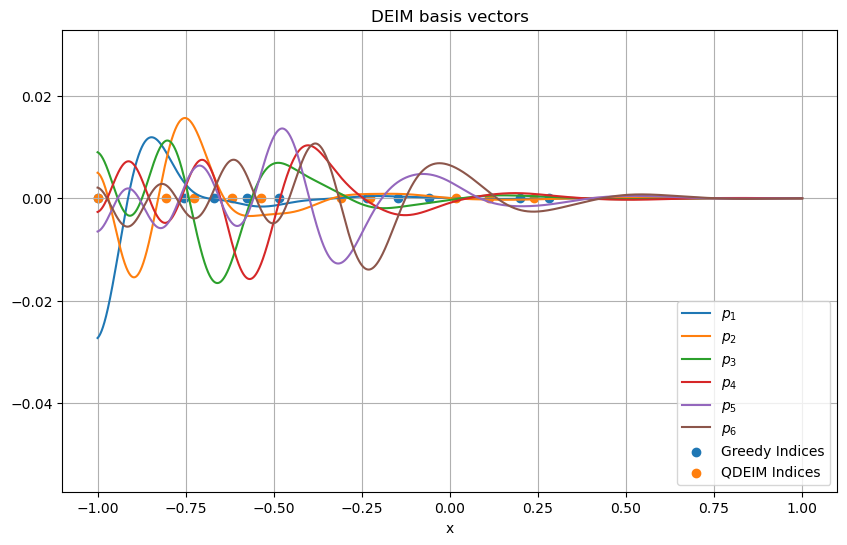

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(6):
    plt.plot(x, U_deim[:, i], label=fr'$p_{{{i+1}}}$')
plt.title('DEIM basis vectors')

plt.scatter(x[greedy_indices], np.zeros_like(x[greedy_indices]), label='Greedy Indices')
plt.scatter(x[qdeim_indices], np.zeros_like(x[qdeim_indices]), label='QDEIM Indices')
plt.legend()
plt.xlabel('x')
# plt.ylabel('Magnitude')
# make yrange [U_deim[:,:6].min, U_deim[:,:6].max] with some padding
plt.ylim([U_deim[:, :6].min() * 2.1, U_deim[:, :6].max() * 2.1])
plt.grid()
plt.show()

In [ ]:
x_syms = sp.IndexedBase('x')
mu_syms = sp.symbols('mu')
f_syms = [sp.cos(3 * sp.pi * mu_syms * (x_syms[i] + 1)) * (1 - x_syms[i]) * sp.exp(-(1 + x_syms[i]) * mu_syms) for i in range(n)]
E_f_greedy_syms = [f_syms[idx] for idx in greedy_indices]
E_f_greedy_syms_func = sp.lambdify([mu_syms, x_syms], E_f_greedy_syms, 'numpy')
E_f_qdeim_syms = [f_syms[idx] for idx in qdeim_indices]
E_f_qdeim_syms_func = sp.lambdify([mu_syms, x_syms], E_f_qdeim_syms, 'numpy')

# Function to run a single DEIM method (A or B)
def run_deim(name, U_deim, indices, mu_test, x_test, method='A'):
    ell = U_deim.shape[1]
    EU = U_deim[indices, :]
    EU_inv = np.linalg.inv(EU)
    if method == 'A':
        # Online phase
        start = time.time()
        if name == 'Greedy':
            E_f_syms_func = E_f_greedy_syms_func
        elif name == 'QDEIM':
            E_f_syms_func = E_f_qdeim_syms_func
        E_f_num = E_f_syms_func(mu_test, x_test)
        c = EU_inv @ E_f_num
        f_deim = U_deim @ c
        end = time.time()
        return f_deim, end - start
    elif method == 'B':
        # True CSR: only evaluate f(x) at required indices
        start = time.time()
        # Evaluate only the required entries
        f_test_indices = f(mu_test, indices)
        c = EU_inv @ f_test_indices
        f_deim = U_deim @ c
        end = time.time()
        return f_deim, end - start
    else:
        raise ValueError('Unknown method')

# Test input
x_test = x
mu_test = np.random.uniform(1, np.pi, size=101)

# Run and average timings for all methods and both index selections
def average_run(name, U_deim, indices, mu_test, x_test, method):
    times = []
    errors = []
    for mu in mu_test:
        f_deim, t = run_deim(name, U_deim, indices, mu, x_test, method)
        f_true = f(mu)
        err = np.linalg.norm(f_true - f_deim) / np.linalg.norm(f_true)
        times.append(t)
        errors.append(err)
    return np.mean(errors), np.std(errors), np.mean(times), np.std(times)

results = {}
for name, idx in [('Greedy', greedy_indices), ('QDEIM', qdeim_indices)]:
    for method in ['A', 'B']:
        err_mean, err_std, t_mean, t_std = average_run(name, U_deim, idx, mu_test, x_test, method)
        results[(name, method)] = (err_mean, err_std, t_mean, t_std)

# Print results
def print_results():
    # LaTeX-friendly table
    print("\\begin{tabular}{lllr}")
    print("\\hline")
    print("Method & Selector & Rel. Error (mean$\\pm$std) & Time (ms, mean$\\pm$std)\\\\")
    print("\\hline")
    for selector in ['Greedy', 'QDEIM']:
        for method in ['A', 'B']:
            err_mean, err_std, t_mean, t_std = results[(selector, method)]
            print(f"{method} & {selector} & {err_mean:.2e} $\\pm$ {err_std:.1e} & {t_mean*1e3:.2f} $\\pm$ {t_std*1e3:.2f}\\\\")
    print("\\hline")
    print("\\end{tabular}")
    print()
    # Context lines (optional)
    print("All times are averages over", len(mu_test), "runs.")
    print("Method A: Symbolic offline-online (SymPy substitution)")
    print("Method B: Chaturantabut2010/CSR (only required entries evaluated)")

if __name__ == '__main__':
    print_results()

\begin{tabular}{lllr}
\hline
Method & Selector & Rel. Error (mean$\pm$std) & Time (ms, mean$\pm$std)\\
\hline
A & Greedy & 3.11e-02 $\pm$ 1.5e-02 & 0.25 $\pm$ 0.06\\
B & Greedy & 3.11e-02 $\pm$ 1.5e-02 & 0.25 $\pm$ 0.03\\
A & QDEIM & 2.00e-02 $\pm$ 5.9e-03 & 0.33 $\pm$ 0.10\\
B & QDEIM & 2.00e-02 $\pm$ 5.9e-03 & 0.29 $\pm$ 0.05\\
\hline
\end{tabular}

All times are averages over 101 runs.
Method A: Symbolic offline-online (SymPy substitution)
Method B: Chaturantabut2010/CSR (only required entries evaluated)


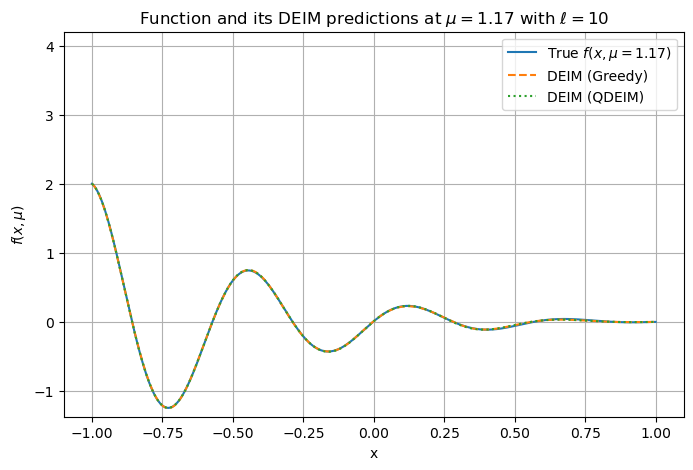

In [ ]:
# Plot sample function and DEIM approximation at mu = 1.17
mu_plot = 1.17
f_sample = f(mu_plot)
# Greedy DEIM approximation
EU_greedy = U_deim[greedy_indices, :]
EU_greedy_inv = np.linalg.inv(EU_greedy)
c_greedy = EU_greedy_inv @ f_sample[greedy_indices]
f_deim_greedy = U_deim @ c_greedy

# QDEIM DEIM approximation
EU_qdeim = U_deim[qdeim_indices, :]
EU_qdeim_inv = np.linalg.inv(EU_qdeim)
c_qdeim = EU_qdeim_inv @ f_sample[qdeim_indices]
f_deim_qdeim = U_deim @ c_qdeim

plt.figure(figsize=(8, 5))
plt.plot(x, f_sample, label=r'True $f(x, \mu=1.17)$')
plt.plot(x, f_deim_greedy, '--', label='DEIM (Greedy)')
plt.plot(x, f_deim_qdeim, ':', label='DEIM (QDEIM)')
plt.title(r'Function and its DEIM predictions at $\mu = 1.17$ with $\ell = 10$')
plt.xlabel('x')
plt.ylabel(r'$f(x, \mu)$')
# Make ylim range [min, max] of all three curves with some padding
y_min = min(f_sample.min(), f_deim_greedy.min(), f_deim_qdeim.min()) * 1.1
y_max = max(f_sample.max(), f_deim_greedy.max(), f_deim_qdeim.max()) * 2.1
plt.ylim([y_min, y_max])
plt.legend()
plt.grid()
plt.show()

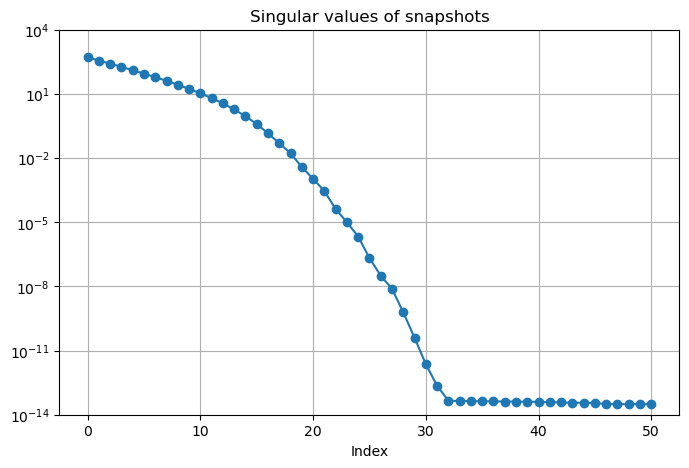

In [ ]:
import numpy as np
import sympy as sp
import time
from scipy.linalg import qr
import matplotlib.pyplot as plt

# Parameters
n = 50000  # dimension of the full system
ell = 10  # DEIM reduced dimension
num_snapshots = 51
x = np.linspace(-1, 1, n)

def getidx(i):
    if i == 0:
        return 0
    elif i < n - 1:
        return i
    else:
        return n - 1

# Nonlinear function (vectorized)
def f(mu, indices=None):
    if indices is None:
        func = (1 - x) * np.cos(3 * np.pi * mu * (x + 1)) * np.exp(-(1 + x) * mu)
    else:
        func = np.zeros_like(x[indices])
        for i, idx in enumerate(indices):
            func[i] = (1 - x[getidx(idx)]) * np.cos(3 * np.pi * mu * (x[getidx(idx)] + 1)) * np.exp(-(1 + x[getidx(idx)]) * mu)
    return func

# Generate snapshots
np.random.seed(0)
snapshots = np.zeros((n, num_snapshots))
mu = np.linspace(1, np.pi, num_snapshots)
for i in range(num_snapshots):
    snapshots[:, i] = f(mu[i])

# SVD for DEIM basis
U, S, Vh = np.linalg.svd(snapshots, full_matrices=False)
U_deim = U[:, :ell]

# Plot the singular values
plt.figure(figsize=(8, 5))
plt.semilogy(S, marker='o')
plt.title('Singular values of snapshots')
plt.xlabel('Index')
# plt.ylabel('Singular Value')
# make yrange [S.min, S.max] rounded to nearest power of 10
plt.ylim([10**(np.floor(np.log10(S.min()*0.9))), 10**(np.ceil(np.log10(S.max()*10)))])
plt.grid()
plt.show()

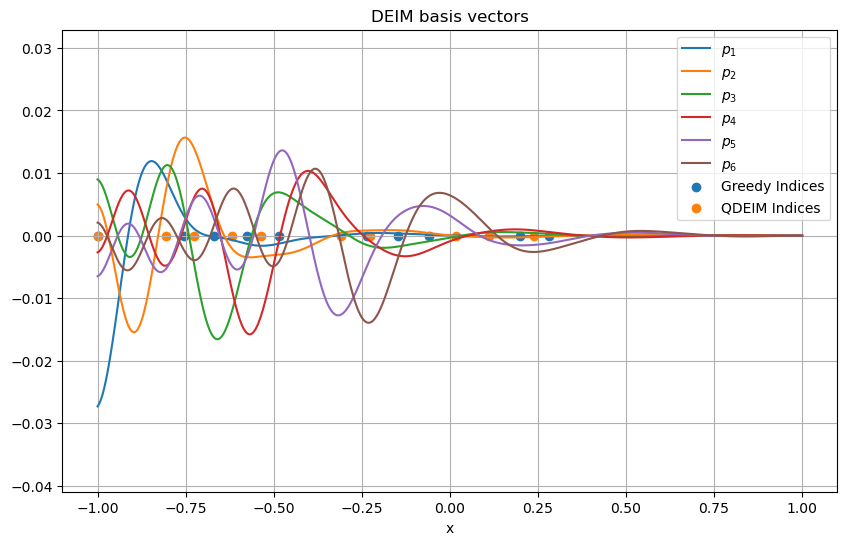

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(6):
    plt.plot(x, U_deim[:, i], label=fr'$p_{{{i+1}}}$')
plt.title('DEIM basis vectors')

plt.scatter(x[greedy_indices], np.zeros_like(x[greedy_indices]), label='Greedy Indices')
plt.scatter(x[qdeim_indices], np.zeros_like(x[qdeim_indices]), label='QDEIM Indices')
plt.legend()
plt.xlabel('x')
# plt.ylabel('Magnitude')
# make yrange [U_deim[:,:6].min, U_deim[:,:6].max] with some padding
plt.ylim([U_deim[:, :6].min() * 1.5, U_deim[:, :6].max() * 2.1])
plt.grid()
plt.show()

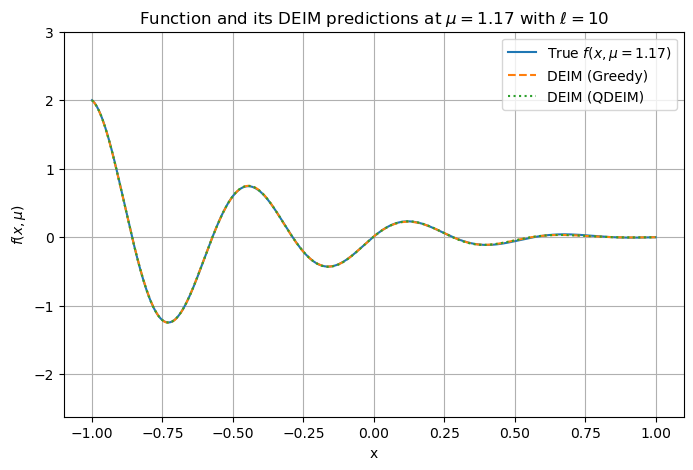

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(x, f_sample, label=r'True $f(x, \mu=1.17)$')
plt.plot(x, f_deim_greedy, '--', label='DEIM (Greedy)')
plt.plot(x, f_deim_qdeim, ':', label='DEIM (QDEIM)')
plt.title(r'Function and its DEIM predictions at $\mu = 1.17$ with $\ell = 10$')
plt.xlabel('x')
plt.ylabel(r'$f(x, \mu)$')
# Make ylim range [min, max] of all three curves with some padding
y_min = min(f_sample.min(), f_deim_greedy.min(), f_deim_qdeim.min()) * 2.1
y_max = max(f_sample.max(), f_deim_greedy.max(), f_deim_qdeim.max()) * 1.5
plt.ylim([y_min, y_max])
plt.legend()
plt.grid()
plt.show()

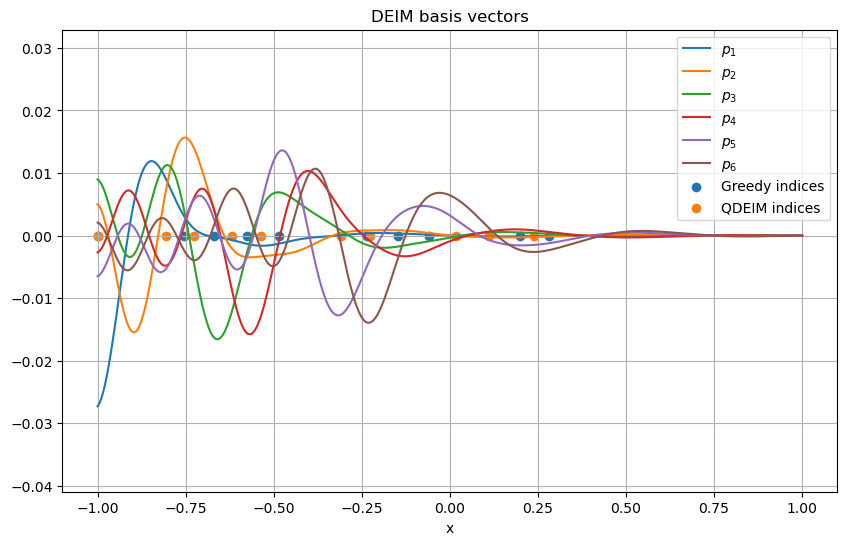

In [ ]:
plt.figure(figsize=(10, 6))
for i in range(6):
    plt.plot(x, U_deim[:, i], label=fr'$p_{{{i+1}}}$')
plt.title('DEIM basis vectors')

plt.scatter(x[greedy_indices], np.zeros_like(x[greedy_indices]), label='Greedy indices')
plt.scatter(x[qdeim_indices], np.zeros_like(x[qdeim_indices]), label='QDEIM indices')
plt.legend()
plt.xlabel('x')
# plt.ylabel('Magnitude')
# make yrange [U_deim[:,:6].min, U_deim[:,:6].max] with some padding
plt.ylim([U_deim[:, :6].min() * 1.5, U_deim[:, :6].max() * 2.1])
plt.grid()
plt.show()

In [ ]:
def plot_deim_approximations(x, f_sample, f_deim_greedy, f_deim_qdeim):
    plt.figure(figsize=(8, 5))
    plt.plot(x, f_sample, label=r'True $f(x, \mu=1.17)$')
    plt.plot(x, f_deim_greedy, '--', label='DEIM (Greedy)')
    plt.plot(x, f_deim_qdeim, ':', label='DEIM (QDEIM)')
    plt.title(r'Function and its DEIM predictions at $\mu = 1.17$ with $\ell = 10$')
    plt.xlabel('x')
    plt.ylabel(r'$f(x, \mu)$')
    # Make ylim range [min, max] of all three curves with some padding
    y_min = min(f_sample.min(), f_deim_greedy.min(), f_deim_qdeim.min()) * 2.1
    y_max = max(f_sample.max(), f_deim_greedy.max(), f_deim_qdeim.max()) * 1.5
    plt.ylim([y_min, y_max])
    plt.legend()
    plt.grid()
    plt.show()

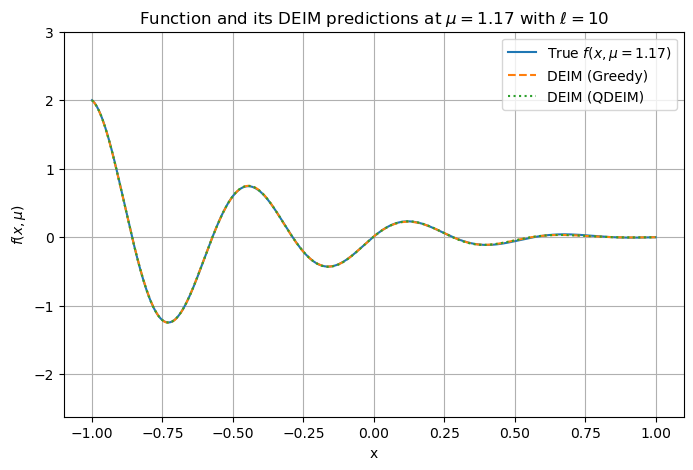

In [ ]:
mu_plot = 1.17
f_sample = f(mu_plot)
# Greedy DEIM approximation (symbolic)
EU_greedy = U_deim[greedy_indices, :]
EU_greedy_inv = np.linalg.inv(EU_greedy)
E_f_greedy_syms_func = E_f_greedy_syms_func
E_f_greedy_num = E_f_greedy_syms_func(mu_plot, x)
c_greedy_sym = EU_greedy_inv @ E_f_greedy_num
f_deim_greedy_sym = U_deim @ c_greedy_sym   

# QDEIM DEIM approximation (symbolic)
EU_qdeim = U_deim[qdeim_indices, :]
EU_qdeim_inv = np.linalg.inv(EU_qdeim)
E_f_qdeim_syms_func = E_f_qdeim_syms_func
E_f_qdeim_num = E_f_qdeim_syms_func(mu_plot, x)
c_qdeim_sym = EU_qdeim_inv @ E_f_qdeim_num
f_deim_qdeim_sym = U_deim @ c_qdeim_sym

plot_deim_approximations(x, f_sample, f_deim_greedy_sym, f_deim_qdeim_sym)

In [ ]:
def plot_deim_approximations(x, f_sample, f_deim_greedy, f_deim_qdeim):
    plt.figure(figsize=(8, 5))
    plt.plot(x, f_sample, label=r'True $f(x, \mu)$')
    plt.plot(x, f_deim_greedy, '--', label='DEIM (Greedy)')
    plt.plot(x, f_deim_qdeim, ':', label='DEIM (QDEIM)')
    plt.title(r'Function and its DEIM predictions at $\mu = 1.17$ with $\ell = 10$')
    plt.xlabel('x')
    plt.ylabel(r'$f(x, \mu)$')
    # Make ylim range [min, max] of all three curves with some padding
    y_min = min(f_sample.min(), f_deim_greedy.min(), f_deim_qdeim.min()) * 2.1
    y_max = max(f_sample.max(), f_deim_greedy.max(), f_deim_qdeim.max()) * 1.5
    plt.ylim([y_min, y_max])
    plt.legend()
    plt.grid()
    plt.show()

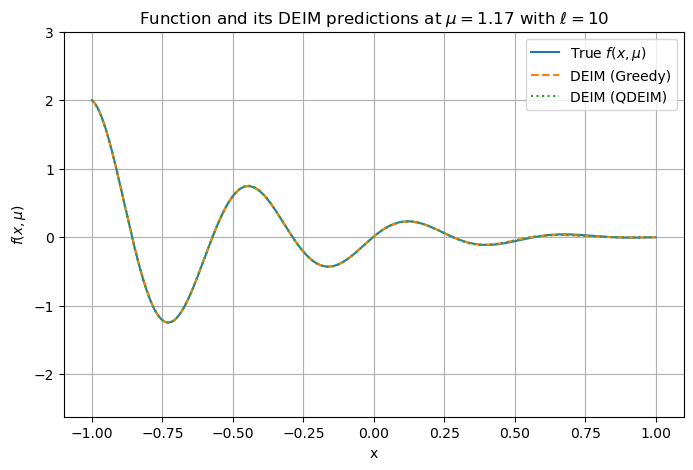

In [ ]:
mu_plot = 1.17
f_sample = f(mu_plot)
# Greedy DEIM approximation (symbolic)
EU_greedy = U_deim[greedy_indices, :]
EU_greedy_inv = np.linalg.inv(EU_greedy)
E_f_greedy_syms_func = E_f_greedy_syms_func
E_f_greedy_num = E_f_greedy_syms_func(mu_plot, x)
c_greedy_sym = EU_greedy_inv @ E_f_greedy_num
f_deim_greedy_sym = U_deim @ c_greedy_sym   

# QDEIM DEIM approximation (symbolic)
EU_qdeim = U_deim[qdeim_indices, :]
EU_qdeim_inv = np.linalg.inv(EU_qdeim)
E_f_qdeim_syms_func = E_f_qdeim_syms_func
E_f_qdeim_num = E_f_qdeim_syms_func(mu_plot, x)
c_qdeim_sym = EU_qdeim_inv @ E_f_qdeim_num
f_deim_qdeim_sym = U_deim @ c_qdeim_sym

plot_deim_approximations(x, f_sample, f_deim_greedy_sym, f_deim_qdeim_sym)